# 🔬 Molecular Fingerprints: Turning Molecules into Numbers
### AI Literacy Project Taster Day — Queen Mary University of London

---

In the SMILES tutorial you learned to represent molecules as text strings.  
But machine learning models don't read text — they need **numbers**.

In this tutorial you will discover how chemists convert molecules into numerical
vectors called **fingerprints**, and how these vectors make it possible to:
- Compare two molecules mathematically
- Search databases of millions of compounds in seconds
- Train machine learning models that predict biological activity

By the end of this notebook you will be able to:
- Explain what a molecular fingerprint is and why it is useful
- Generate **MACCS** and **Morgan** fingerprints using RDKit
- Visualise and compare fingerprints across a set of molecules
- Understand when each fingerprint type is most appropriate

> 💡 **How to run a cell:** Click on it, then press **Shift + Enter**.  
> Run cells **in order from top to bottom**.

---


## Section 0 — Installing Required Packages 🛠️


In [1]:
# install deepchem and rdkit
! pip install deepchem
! pip install rdkit

---
## Section 1 — What is a Molecular Fingerprint? 🧬

### The core problem: machines can't read molecules

Imagine you want to teach a computer to predict whether a molecule is toxic.  
You have thousands of examples — but how do you feed a molecule into an algorithm?

You can't hand it a structural drawing.  
You *could* hand it a SMILES string, but most ML algorithms expect numbers.

The solution is a **molecular fingerprint**: a fixed-length vector of 0s and 1s
that encodes which chemical features are present in the molecule.

```
Aspirin → [0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, ...]   (167 or 2048 numbers)
Caffeine → [0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, ...]
```

Each **position** in the vector corresponds to a specific chemical feature.  
A **1** means "this feature is present", a **0** means "it is absent".

---

### Two main fingerprint types covered today

| Fingerprint | Full name | Key idea | Vector length |
|-------------|-----------|----------|---------------|
| **MACCS** | Molecular ACCess System | Fixed list of 166 predefined chemical questions | 166 bits |
| **Morgan** | Morgan / ECFP | Circular neighbourhood around each atom | Typically 512–2048 bits |

> 💬 **Think of it like this:**  
> MACCS is like a **checklist** — "Does the molecule have a ring? Does it have an OH group? Does it have nitrogen?"  
> Morgan is like a **postcode** — it encodes the local chemical environment around each atom.

---


## Section 2 — Loading Our Tools 📦

We import all the libraries we need at the start. Notice two new RDKit modules:
- `MACCSkeys` — generates MACCS fingerprints
- `AllChem` — provides Morgan fingerprint functions


In [2]:
# ── Standard libraries ─────────────────────────────────────────────────────────
from rdkit import Chem
from rdkit.Chem import MACCSkeys, AllChem, Draw
from rdkit import DataStructs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

print("✅ All tools loaded successfully!")


✅ All tools loaded successfully!


---
## Section 3 — MACCS Keys Fingerprints 🗝️

### 3a — Your first fingerprint

The MACCS keys system defines **166 structural questions** about a molecule.  
For example:
- Bit 92: "Does the molecule contain a ring?"
- Bit 139: "Does it have an aromatic ring?"
- Bit 160: "Does it contain an oxygen atom?"

Let's generate the MACCS fingerprint for **ethane** (`CC`) — a simple two-carbon molecule.


In [3]:
from rdkit import Chem
from rdkit.Chem import MACCSkeys

# Define the SMILES string
smiles = "CC"

# Convert SMILES to RDKit molecule object
mol = Chem.MolFromSmiles(smiles)

# Generate MACCS keys fingerprint
maccs_fp = MACCSkeys.GenMACCSKeys(mol)

# Print the fingerprint as a bit string
print(maccs_fp.ToBitString())


00000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000100000000001000000


> 💬 **Reading the output:**  
> The fingerprint is a long string of 0s and 1s — 166 characters in total.  
> Most are 0 because ethane is a very simple molecule with very few features.  
> Can you count how many 1s there are?  
>
> Each `1` represents a chemical feature that RDKit detected in ethane.  
> Because ethane has only C–C and C–H bonds, almost all bits are 0.

---
### 3b — Visualising the fingerprint as a heatmap

A bit string is hard to read. Let's visualise it as a colour grid instead.


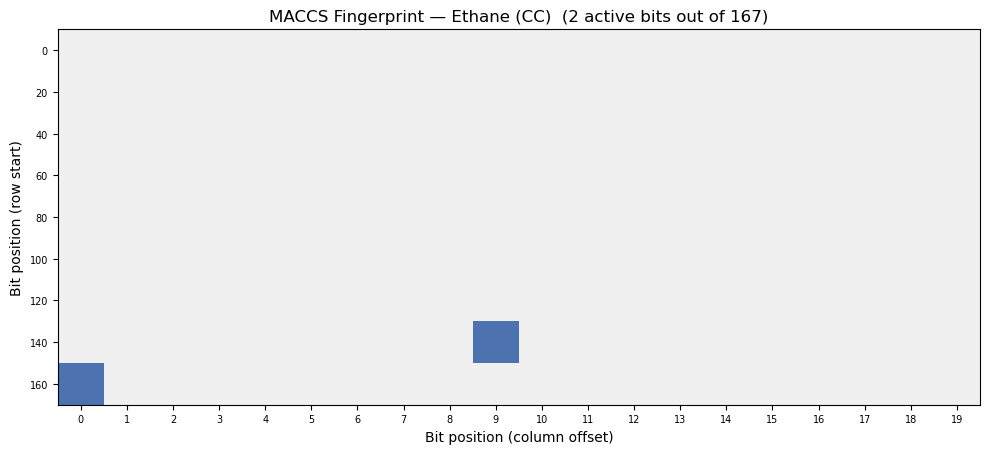

In [4]:
def plot_fingerprint(fp_bitstring: str, title: str, color: str = "steelblue") -> None:
    """
    Visualise a fingerprint bit string as a colour heatmap.

    Parameters
    ----------
    fp_bitstring : str  — binary string of 0s and 1s
    title        : str  — plot title
    color        : str  — colour for active bits
    """
    bits = np.array([int(b) for b in fp_bitstring])
    n    = len(bits)
    cols = 20
    rows = (n + cols - 1) // cols
    grid = np.zeros(rows * cols)
    grid[:n] = bits
    grid = grid.reshape(rows, cols)

    cmap = mcolors.ListedColormap(["#f0f0f0", color])
    fig, ax = plt.subplots(figsize=(10, rows * 0.45 + 0.6))
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=1, aspect="auto")
    ax.set_title(f"{title}  ({int(bits.sum())} active bits out of {n})",
                 fontsize=12)
    ax.set_xticks(range(cols))
    ax.set_xticklabels(range(0, cols), fontsize=7)
    ax.set_yticks(range(rows))
    ax.set_yticklabels(range(0, rows * cols, cols), fontsize=7)
    ax.set_xlabel("Bit position (column offset)")
    ax.set_ylabel("Bit position (row start)")
    plt.tight_layout()
    plt.show()

# ── Generate and visualise ethane fingerprint ──────────────────────────────────
mol_ethane = Chem.MolFromSmiles("CC")
fp_ethane  = MACCSkeys.GenMACCSKeys(mol_ethane)
plot_fingerprint(fp_ethane.ToBitString(), "MACCS Fingerprint — Ethane (CC)", "#4C72B0")


---
### 3c — Compare fingerprints across familiar molecules

Now let's compare the MACCS fingerprints of four molecules you've seen before.  
Notice how more complex molecules have more active bits.


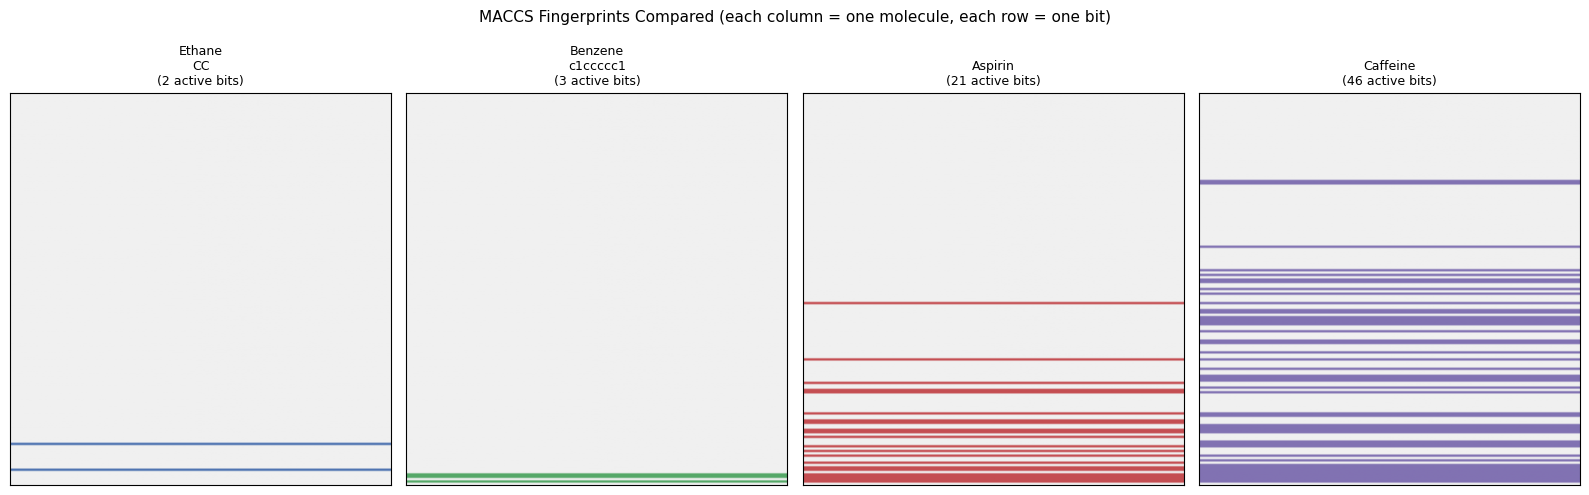

In [5]:
# ── Compare MACCS fingerprints ─────────────────────────────────────────────────
compare_molecules = {
    "Ethane\nCC"           : "CC",
    "Benzene\nc1ccccc1"    : "c1ccccc1",
    "Aspirin"               : "CC(=O)Oc1ccccc1C(=O)O",
    "Caffeine"              : "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",
}

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for ax, (name, smiles), color in zip(axes, compare_molecules.items(), colors):
    mol = Chem.MolFromSmiles(smiles)
    fp  = MACCSkeys.GenMACCSKeys(mol)
    bits = np.array([int(b) for b in fp.ToBitString()])
    cmap = mcolors.ListedColormap(["#f0f0f0", color])
    ax.imshow(bits.reshape(-1, 1), cmap=cmap, vmin=0, vmax=1, aspect="auto")
    ax.set_title(f"{name}\n({int(bits.sum())} active bits)", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("MACCS Fingerprints Compared (each column = one molecule, each row = one bit)",
             fontsize=11)
plt.tight_layout()
plt.show()


> 💬 **What do you notice?**
> - Which molecule has the fewest active bits? Does that make sense chemically?
> - Aspirin and caffeine are more complex — do they have more active bits?
> - Are there any bits that are active in ALL four molecules?

---


## Section 4 — Building a Molecule Dataset 📊

### 4a — Create a DataFrame of molecules

Before generating fingerprints at scale, we need our molecules in a structured
table (**DataFrame**). The `ROMol` column stores RDKit molecule objects — think
of these as "parsed" molecules that RDKit can work with directly.


In [10]:
import pandas as pd

df = pd.DataFrame(
   data={
       'smiles': [
           'CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C',
           'CC(=O)OC(CC(=O)O)C[N+](C)(C)C',
           'CC(CN)O',
           'C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl',
           'CCN1C=NC2=C(N=CN=C21)N',
           'CCC(C)(C(C(=O)O)O)O',
           'C(CCl)Cl',
           'C1=CC(=C(C=C1Cl)Cl)Cl',
           'C1CCC(=O)NCCCCCC(=O)NCC1',
           'C1C=CC(=NC1C(=O)O)C(=O)O'
       ],
       'mw': [
           203.24, 204.24, 75.11, 202.55, 163.18, 148.16, 98.96, 181.4, 226.32, 169.13
       ]
   }
)

df

,smiles,mw
0,CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C,203.24
1,CC(=O)OC(CC(=O)O)C[N+](C)(C)C,204.24
2,CC(CN)O,75.11
3,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,202.55
4,CCN1C=NC2=C(N=CN=C21)N,163.18
5,CCC(C)(C(C(=O)O)O)O,148.16
6,C(CCl)Cl,98.96
7,C1=CC(=C(C=C1Cl)Cl)Cl,181.40
8,C1CCC(=O)NCCCCCC(=O)NCC1,226.32
9,C1C=CC(=NC1C(=O)O)C(=O)O,169.13


> 💬 **What is a DataFrame?** It's a table where each row is a molecule and
> each column is a property — just like a spreadsheet in Excel.  
> The `mw` column gives the molecular weight in Daltons (Da).


In [13]:
from rdkit.Chem import PandasTools

# ── Add RDKit molecule objects from the SMILES column ─────────────────────────
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles', molCol='ROMol')

print(f"✅ ROMol column added. DataFrame shape: {df.shape}")
df.head(3)

✅ ROMol column added. DataFrame shape: (10, 3)


,smiles,mw,ROMol
0,CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C,203.24,<rdkit.Chem.rdchem.Mol object at 0x00000200639...
1,CC(=O)OC(CC(=O)O)C[N+](C)(C)C,204.24,<rdkit.Chem.rdchem.Mol object at 0x00000200639...
2,CC(CN)O,75.11,<rdkit.Chem.rdchem.Mol object at 0x00000200639...


,smiles,mw,ROMol,maccs
0,CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C,203.24,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CC(=O)OC(CC(=O)O)C[N+](C)(C)C,204.24,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CC(CN)O,75.11,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,202.55,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CCN1C=NC2=C(N=CN=C21)N,163.18,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,CCC(C)(C(C(=O)O)O)O,148.16,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,C(CCl)Cl,98.96,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,C1=CC(=C(C=C1Cl)Cl)Cl,181.40,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,C1CCC(=O)NCCCCCC(=O)NCC1,226.32,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,C1C=CC(=NC1C(=O)O)C(=O)O,169.13,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."

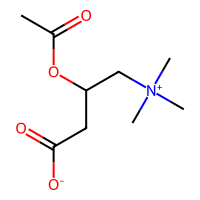
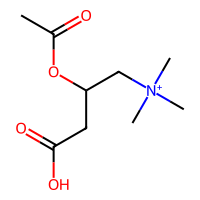
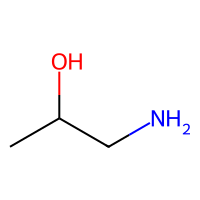
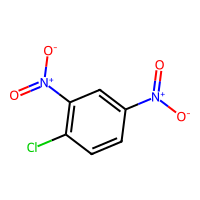
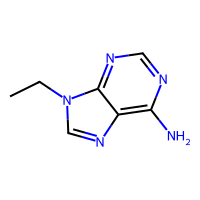
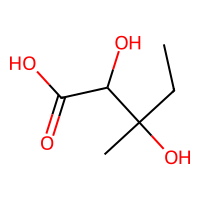
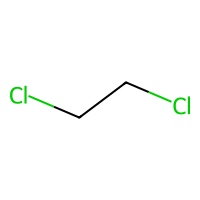
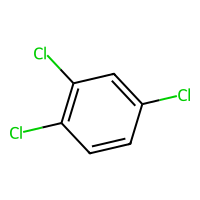
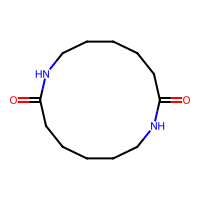
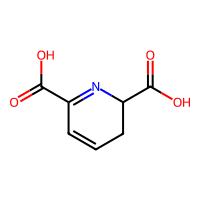

In [14]:
from rdkit.Chem import MACCSkeys

def maccs_fp(mol):
    return MACCSkeys.GenMACCSKeys(mol)

df['maccs'] = df['ROMol'].apply(maccs_fp)
df

> 💬 **Why store molecule objects?** The `ROMol` column lets us call RDKit
> functions directly on each molecule using pandas' `apply()` method — 
> much faster than re-parsing the SMILES string every time.

---


## Section 5 — Generating MACCS Fingerprints for the Whole Dataset 🗃️

Now we apply the MACCS fingerprint function to every molecule in the dataset
using a single line of pandas code — `df['ROMol'].apply(maccs_fp)`.

`apply()` is a powerful pandas method that runs a function on every row of a
column. It's the equivalent of a for loop, but more concise.


,smiles,mw,ROMol,maccs
0,CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C,203.24,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CC(=O)OC(CC(=O)O)C[N+](C)(C)C,204.24,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CC(CN)O,75.11,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,202.55,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CCN1C=NC2=C(N=CN=C21)N,163.18,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,CCC(C)(C(C(=O)O)O)O,148.16,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,C(CCl)Cl,98.96,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,C1=CC(=C(C=C1Cl)Cl)Cl,181.40,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,C1CCC(=O)NCCCCCC(=O)NCC1,226.32,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,C1C=CC(=NC1C(=O)O)C(=O)O,169.13,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."

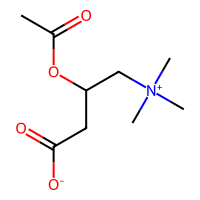
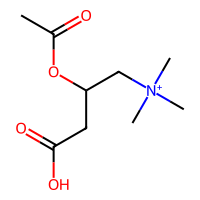
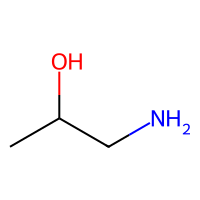
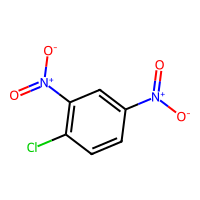
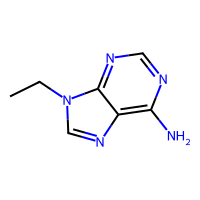
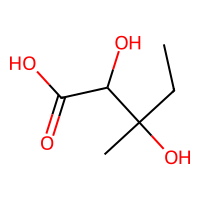
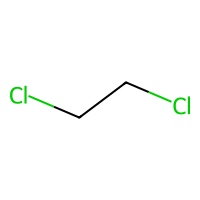
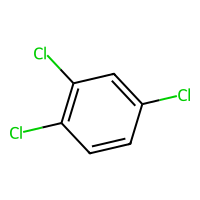
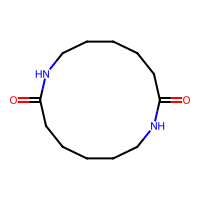
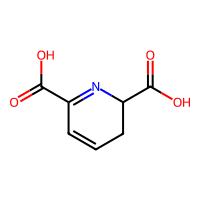

In [15]:
from rdkit.Chem import MACCSkeys

def maccs_fp(mol):
    return MACCSkeys.GenMACCSKeys(mol)

df['maccs'] = df['ROMol'].apply(maccs_fp)
df

> 💬 **Reading the table:** Each entry in the `maccs` column is a list of
> 167 numbers (0 or 1). Together they form the fingerprint for that molecule.

---
### 5b — Visualise the MACCS fingerprint matrix

Let's visualise all 10 molecules' fingerprints as a heatmap — rows are molecules,
columns are MACCS bit positions.


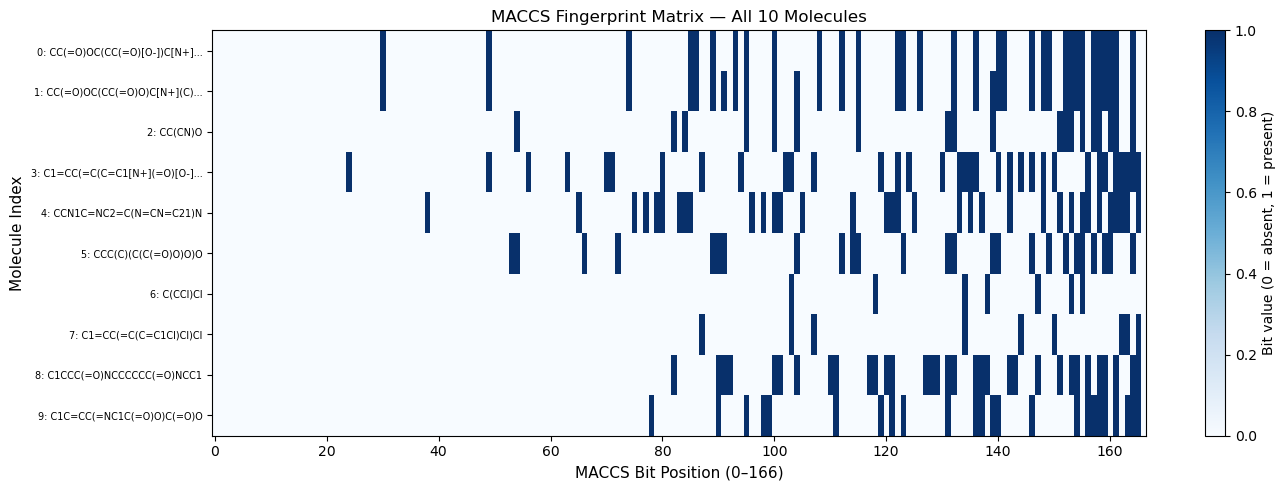

In [16]:
# ── Build the fingerprint matrix ───────────────────────────────────────────────
maccs_matrix = np.array(df['maccs'].tolist())

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(maccs_matrix, cmap="Blues", aspect="auto", interpolation="nearest")
ax.set_xlabel("MACCS Bit Position (0–166)", fontsize=11)
ax.set_ylabel("Molecule Index", fontsize=11)
ax.set_title("MACCS Fingerprint Matrix — All 10 Molecules", fontsize=12)
ax.set_yticks(range(len(df)))
ax.set_yticklabels([f"{i}: {s[:25]}..." if len(s) > 25 else f"{i}: {s}"
                    for i, s in enumerate(df['smiles'])], fontsize=7)
plt.colorbar(im, ax=ax, label="Bit value (0 = absent, 1 = present)")
plt.tight_layout()
plt.show()


> 💬 **How to read this heatmap:**
> - Each **row** is one molecule
> - Each **column** is one MACCS bit position
> - A **dark blue cell** means that bit is active (the feature is present)
>
> Do any molecules share many active bits? Those are likely to be chemically similar.

---


## Section 6 — Morgan Fingerprints (Circular Fingerprints) 🔄

### How Morgan fingerprints work

Morgan fingerprints take a fundamentally different approach to MACCS.  
Rather than checking a fixed list of structural features, they encode the
**local chemical environment** around each atom.

The process works in **three steps**:

1. **Start at each atom** — assign it an identifier based on its element,
   charge, and whether it's in a ring
2. **Expand outwards** — at each "radius" step, include information about
   neighbouring atoms (radius 1 = immediate neighbours, radius 2 = neighbours
   of neighbours, etc.)
3. **Hash to a bit vector** — map each neighbourhood pattern to a position
   in a fixed-length binary vector

```
Radius 0:  just the atom itself         → captures atom type
Radius 1:  atom + its direct bonds      → captures functional groups  
Radius 2:  atom + 2-bond neighbourhood  → captures ring environments
```

> 💬 **Analogy:** Imagine describing a city by its postcodes.  
> Each atom gets a "postcode" that encodes everything within 2 streets of it.  
> Two atoms in different molecules with the same chemical environment get the
> same postcode — and therefore activate the same bit.

---
### 6a — Binary vs Count Morgan fingerprints

There are two variants:

| Type | What it stores | Best for |
|------|---------------|----------|
| **Binary** | 1 if a pattern is present, else 0 | Similarity searching |
| **Count** | How many times each pattern appears | Quantitative ML models |


,smiles,mw,ROMol,maccs,morgan
0,CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C,203.24,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
1,CC(=O)OC(CC(=O)O)C[N+](C)(C)C,204.24,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
2,CC(CN)O,75.11,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,202.55,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CCN1C=NC2=C(N=CN=C21)N,163.18,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
5,CCC(C)(C(C(=O)O)O)O,148.16,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,C(CCl)Cl,98.96,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,C1=CC(=C(C=C1Cl)Cl)Cl,181.40,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,C1CCC(=O)NCCCCCC(=O)NCC1,226.32,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,C1C=CC(=NC1C(=O)O)C(=O)O,169.13,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."

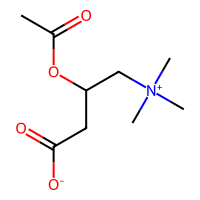
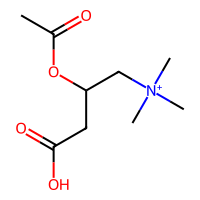
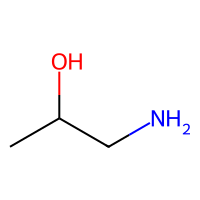
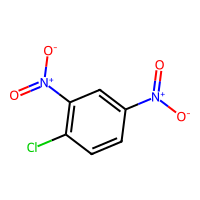
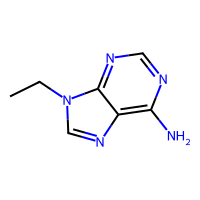
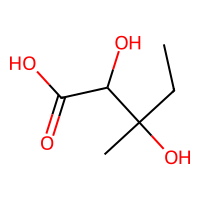
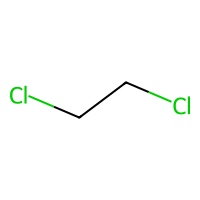
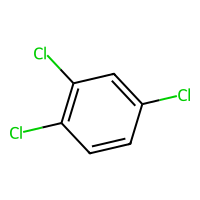
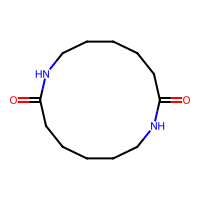
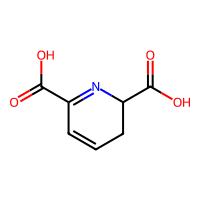

In [17]:
from rdkit.Chem import AllChem

def morgan_fp(mol):
   morgan = AllChem.GetMorganGenerator(radius=2, fpSize=512)
   return morgan.GetFingerprint(mol)

df['morgan'] = df['ROMol'].apply(morgan_fp)
df

> 💬 **`radius=2, fpSize=512`** means:  
> - Look at each atom and its neighbours up to 2 bonds away  
> - Map the results into a vector of 512 positions  
> A larger `fpSize` reduces "hash collisions" (two different features mapping
> to the same bit), but uses more memory.

---
### 6b — Count Morgan fingerprints


,smiles,mw,ROMol,maccs,morgan,morgan_count
0,CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C,203.24,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
1,CC(=O)OC(CC(=O)O)C[N+](C)(C)C,204.24,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
2,CC(CN)O,75.11,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl,202.55,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CCN1C=NC2=C(N=CN=C21)N,163.18,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
5,CCC(C)(C(C(=O)O)O)O,148.16,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,C(CCl)Cl,98.96,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7,C1=CC(=C(C=C1Cl)Cl)Cl,181.40,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
8,C1CCC(=O)NCCCCCC(=O)NCC1,226.32,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 2, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
9,C1C=CC(=NC1C(=O)O)C(=O)O,169.13,,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."

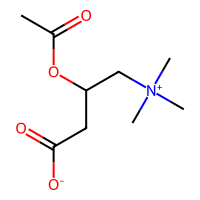
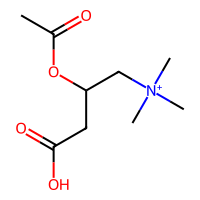
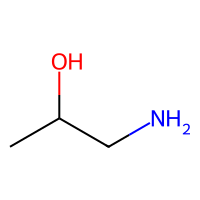
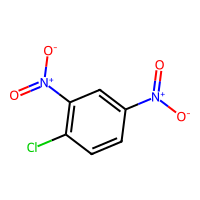
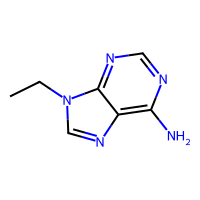
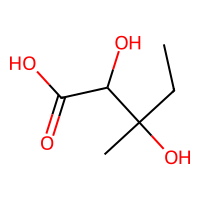
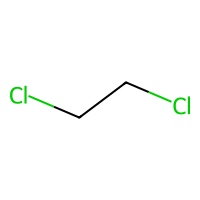
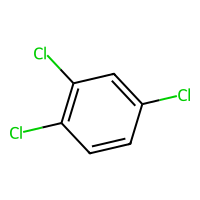
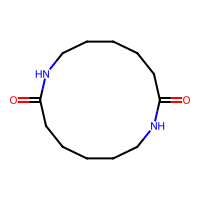
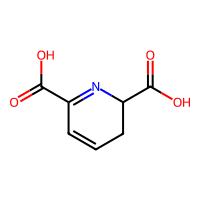

In [18]:
from rdkit import DataStructs
import numpy as np

def morgan_count_fp(mol):
   morgan = AllChem.GetMorganGenerator(radius=2, fpSize=512)
   object = morgan.GetCountFingerprint(mol)
   
   fp = np.zeros((0,), dtype=np.int8)
   DataStructs.ConvertToNumpyArray(object, fp)
   return fp

df['morgan_count'] = df['ROMol'].apply(morgan_count_fp)
df

> 💬 **Binary vs Count:** In the count fingerprint, a value of 2 or 6 in the
> `morgan_count` column means that particular molecular environment appears
> multiple times in the molecule. This gives the model more information than
> just "present or absent".

---
### 6c — Comparing MACCS vs Morgan visually


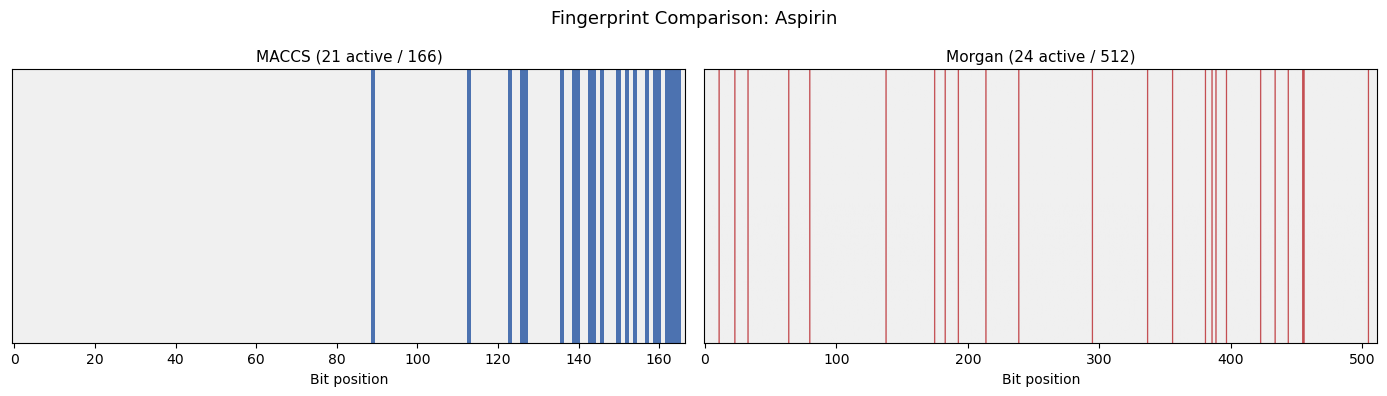

MACCS  : 21 active bits out of 166
Morgan : 24 active bits out of 512
Density: MACCS = 12.6%  |  Morgan = 4.7%


In [19]:
# ── Side-by-side comparison for one molecule ───────────────────────────────────
test_smiles = "CC(=O)Oc1ccccc1C(=O)O"   # aspirin
test_mol    = Chem.MolFromSmiles(test_smiles)
test_name   = "Aspirin"

# MACCS fingerprint
maccs_fp_test = MACCSkeys.GenMACCSKeys(test_mol)
maccs_bits    = np.array([int(b) for b in maccs_fp_test.ToBitString()])

# Morgan binary fingerprint
morgan_gen   = AllChem.GetMorganGenerator(radius=2, fpSize=512)
morgan_obj   = morgan_gen.GetFingerprint(test_mol)
morgan_bits  = np.zeros(512, dtype=np.int8)
DataStructs.ConvertToNumpyArray(morgan_obj, morgan_bits)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, bits, title, color, label in [
    (axes[0], maccs_bits,  f"MACCS ({int(maccs_bits.sum())} active / 166)",  "#4C72B0", "MACCS"),
    (axes[1], morgan_bits, f"Morgan ({int(morgan_bits.sum())} active / 512)", "#C44E52", "Morgan"),
]:
    cmap = mcolors.ListedColormap(["#f0f0f0", color])
    ax.imshow(bits.reshape(1, -1), cmap=cmap, vmin=0, vmax=1, aspect="auto")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Bit position")
    ax.set_yticks([])

plt.suptitle(f"Fingerprint Comparison: {test_name}", fontsize=13)
plt.tight_layout()
plt.show()

print(f"MACCS  : {int(maccs_bits.sum())} active bits out of 166")
print(f"Morgan : {int(morgan_bits.sum())} active bits out of 512")
print(f"Density: MACCS = {maccs_bits.mean()*100:.1f}%  |  Morgan = {morgan_bits.mean()*100:.1f}%")


> 💬 **Key difference:**  
> MACCS fingerprints tend to be **denser** (more 1s) because they check for
> general features that many molecules share. Morgan fingerprints are **sparser**
> because they encode very specific local environments.  
> Sparser fingerprints can actually be better for distinguishing very similar molecules.

---


## Section 7 — Using Fingerprints for Similarity Searching 🔍

Now we connect fingerprints back to the **Tanimoto similarity** you saw in the
SMILES tutorial. The formula is the same — but now you understand *why* it works:
we're measuring the overlap between two bit vectors.

$$T(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{\text{bits active in both}}{\text{bits active in either}}$$

Let's compare **aspirin** against all 10 molecules in our dataset, using both
MACCS and Morgan fingerprints, and see if they give different rankings.


In [20]:
# ── Similarity of aspirin vs all molecules in df ──────────────────────────────
aspirin_mol    = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")

# MACCS similarity
aspirin_maccs  = MACCSkeys.GenMACCSKeys(aspirin_mol)

# Morgan similarity
morgan_gen     = AllChem.GetMorganGenerator(radius=2, fpSize=512)
aspirin_morgan = morgan_gen.GetFingerprint(aspirin_mol)

rows = []
for _, row in df.iterrows():
    mol   = row['ROMol']
    m_sim = DataStructs.FingerprintSimilarity(
                aspirin_maccs, MACCSkeys.GenMACCSKeys(mol))
    fp_m  = morgan_gen.GetFingerprint(mol)
    mg_sim= DataStructs.FingerprintSimilarity(aspirin_morgan, fp_m)
    rows.append({
        "SMILES"             : row['smiles'],
        "MACCS Similarity"   : round(m_sim,  3),
        "Morgan Similarity"  : round(mg_sim, 3),
    })

sim_df = (pd.DataFrame(rows)
            .sort_values("MACCS Similarity", ascending=False)
            .reset_index(drop=True))

print("Similarity to Aspirin (CC(=O)Oc1ccccc1C(=O)O):\n")
print(sim_df.to_string(index=False))


Similarity to Aspirin (CC(=O)Oc1ccccc1C(=O)O):

                                   SMILES  MACCS Similarity  Morgan Similarity
                 C1C=CC(=NC1C(=O)O)C(=O)O             0.324              0.175
                      CCC(C)(C(C(=O)O)O)O             0.314              0.167
            CC(=O)OC(CC(=O)O)C[N+](C)(C)C             0.302              0.225
         CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C             0.293              0.190
C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])Cl             0.222              0.119
                    C1=CC(=C(C=C1Cl)Cl)Cl             0.200              0.086
                 C1CCC(=O)NCCCCCC(=O)NCC1             0.149              0.051
                                  CC(CN)O             0.143              0.094
                   CCN1C=NC2=C(N=CN=C21)N             0.078              0.109
                                 C(CCl)Cl             0.000              0.036


> 💬 **Questions:**
> 1. Which molecule in the dataset is most similar to aspirin according to MACCS?
> 2. Does Morgan give the same ranking? If not, why might they differ?
> 3. Why does aspirin score 1.0 against itself?

---


## Section 8 — Which Fingerprint Should You Use? 🤔

There is no single "best" fingerprint — the right choice depends on your task.

| Task | Recommended fingerprint | Why |
|------|------------------------|-----|
| Similarity search (find molecules like a known drug) | Morgan (ECFP4/ECFP6) | Captures specific local environments; good at distinguishing similar scaffolds |
| Substructure search (does it have a specific fragment?) | MACCS | Directly encodes named fragments |
| Machine learning (QSAR models) | Morgan count | Richer information; count captures repetition |
| Visualisation / interpretability | MACCS | Only 166 bits; bits have named meanings |

### The radius parameter matters for Morgan fingerprints


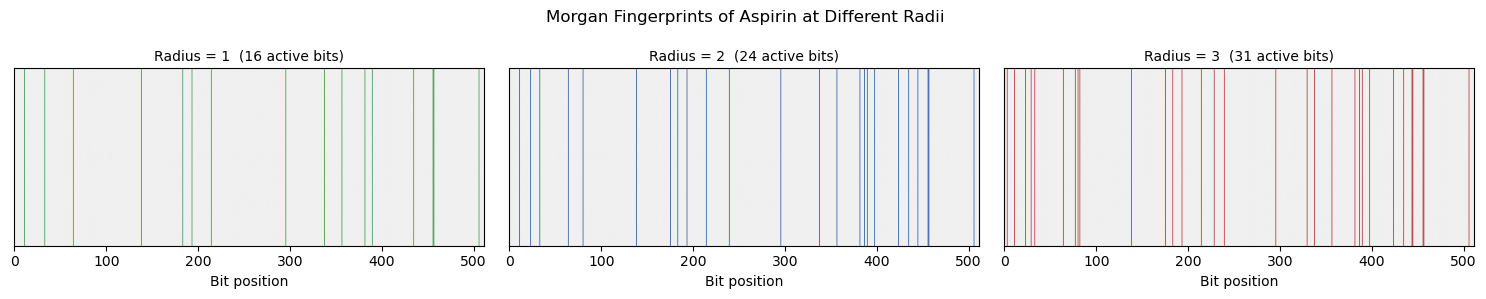

Interpretation:
  Radius 1 → captures atoms and their immediate bonds (functional groups)
  Radius 2 → captures atoms + 2-bond neighbourhoods (ring environments)
  Radius 3 → wider context; more unique patterns, fewer active bits


In [21]:
# ── Effect of Morgan radius on fingerprint density ────────────────────────────
test_mol    = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")   # aspirin
radii       = [1, 2, 3]
fp_sizes    = [512, 512, 512]

fig, axes = plt.subplots(1, 3, figsize=(15, 3))
colors     = ["#55A868", "#4C72B0", "#C44E52"]

for ax, radius, color in zip(axes, radii, colors):
    gen   = AllChem.GetMorganGenerator(radius=radius, fpSize=512)
    fp    = gen.GetFingerprint(test_mol)
    bits  = np.zeros(512, dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, bits)
    cmap  = mcolors.ListedColormap(["#f0f0f0", color])
    ax.imshow(bits.reshape(1, -1), cmap=cmap, vmin=0, vmax=1, aspect="auto")
    ax.set_title(f"Radius = {radius}  ({int(bits.sum())} active bits)", fontsize=10)
    ax.set_xlabel("Bit position")
    ax.set_yticks([])

plt.suptitle("Morgan Fingerprints of Aspirin at Different Radii", fontsize=12)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Radius 1 → captures atoms and their immediate bonds (functional groups)")
print("  Radius 2 → captures atoms + 2-bond neighbourhoods (ring environments)")
print("  Radius 3 → wider context; more unique patterns, fewer active bits")


> 💬 Notice how **increasing the radius decreases the number of active bits**.  
> At larger radii, patterns become more specific and therefore rarer — fewer
> atoms in the molecule will match a very detailed neighbourhood description.

---


## Section 9 — Summary & Discussion 💬

### What you covered today

| Concept | Key takeaway |
|---------|-------------|
| Molecular fingerprints | Fixed-length binary vectors encoding which chemical features are present |
| MACCS keys | 166 predefined structural questions; interpretable; good for substructure search |
| Morgan (ECFP) | Circular neighbourhood encoding; tunable radius; best for ML and similarity search |
| Binary vs count | Binary = presence/absence; count = how many times; count is richer for ML |
| Tanimoto similarity | Overlap between two fingerprint vectors; ranges 0 (different) to 1 (identical) |

---

### Discussion questions

1. **Information loss:** A SMILES string contains complete structural information.
   A 166-bit MACCS fingerprint does not. What types of information are lost in the
   conversion? Does this matter for drug discovery?

2. **Hash collisions:** Morgan fingerprints use a mathematical "hash function" to
   map neighbourhood patterns to bit positions. Two different patterns can
   occasionally map to the *same* bit (a collision). How might this affect
   similarity calculations?

3. **Radius choice:** Increasing the Morgan radius makes patterns more specific.
   What happens to similarity scores between structurally related drugs as you
   increase the radius? Does this make the fingerprint more or less useful?

4. **Machine learning:** A neural network trained on Morgan fingerprints to
   predict drug toxicity learns which bit combinations correlate with toxicity.
   But it doesn't "know" what those bits mean chemically. Is this a problem?

5. **Beyond binary:** Researchers have developed 3D fingerprints that encode
   the *shape* of a molecule, not just its 2D structure. When might a 3D
   fingerprint be more useful than a 2D one?

---

### What comes next?

| Topic | Description |
|-------|-------------|
| **QSAR modelling** | Use Morgan fingerprints as inputs to train ML models that predict biological activity |
| **Dimensionality reduction** | Compress 512-bit fingerprints to 2D using PCA or UMAP to visualise chemical space |
| **Graph neural networks** | Skip fingerprints entirely — feed the molecular graph directly into a neural network |
| **Virtual screening** | Search libraries of billions of compounds using fingerprint similarity |

---

### Further Reading

- DeepChem fingerprints tutorial: https://deepchem.io/tutorials/molecular-fingerprints/
- Rogers & Hahn, ECFP fingerprints: *J. Chem. Inf. Model.*, 2010, **50**, 742–754
- Bajusz et al., Tanimoto comparison: *J. Cheminform.*, 2015, **7**, 20
- RDKit fingerprints documentation: https://www.rdkit.org/docs/GettingStartedInPython.html#fingerprinting-and-molecular-similarity

---
*Notebook developed for the QMUL AI Literacy Project Taster Day · Department of Chemistry*
